# **Step 1 — Import Libraries**

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.datasets import GTSRB

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np

import os

## **Step 2 — Configuration / Hyperparameters**

In [5]:
# Hyperparameters

batch_size = 64
learning_rate = 0.001
epochs = 10

# **3 - Load and Preprocess GTSRB Dataset**

In [6]:
# Transform
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

# Dataset
train_dataset = GTSRB(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = GTSRB(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

classes = list(set(label for _ , label in train_dataset))

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))
print("Number of classes:", len(classes))

100%|██████████| 187M/187M [00:17<00:00, 10.8MB/s]
100%|██████████| 89.0M/89.0M [00:08<00:00, 10.3MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 218kB/s]


Training images: 26640
Testing images: 12630
Number of classes: 43


## **3.1 - Mapping Class Names**

In [41]:
class_names = {
0: "Speed limit (20km/h)",
1: "Speed limit (30km/h)",
2: "Speed limit (50km/h)",
3: "Speed limit (60km/h)",
4: "Speed limit (70km/h)",
5: "Speed limit (80km/h)",
6: "End of speed limit (80km/h)",
7: "Speed limit (100km/h)",
8: "Speed limit (120km/h)",
9: "No passing",
10: "No passing for vehicles over 3.5 tons",
11: "Right-of-way at intersection",
12: "Priority road",
13: "Yield",
14: "Stop",
15: "No vehicles",
16: "Vehicles over 3.5 tons prohibited",
17: "No entry",
18: "General caution",
19: "Dangerous curve left",
20: "Dangerous curve right",
21: "Double curve",
22: "Bumpy road",
23: "Slippery road",
24: "Road narrows on right",
25: "Road work",
26: "Traffic signals",
27: "Pedestrians",
28: "Children crossing",
29: "Bicycles crossing",
30: "Beware of ice/snow",
31: "Wild animals crossing",
32: "End speed + passing limits",
33: "Turn right ahead",
34: "Turn left ahead",
35: "Ahead only",
36: "Go straight or right",
37: "Go straight or left",
38: "Keep right",
39: "Keep left",
40: "Roundabout mandatory",
41: "End of no passing",
42: "End no passing >3.5 tons"
}

## **3.2 - Visualizing Dataset Sample**

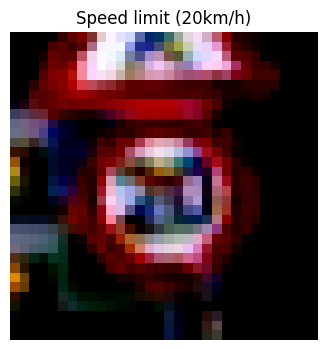

Shape: torch.Size([3, 32, 32])
Label: 0


In [44]:
image, label = train_dataset[0]

plt.figure(figsize=(4,4))
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis("off")

plt.show()


print("Shape:", image.shape)
print("Label:", label)

# **4 - Create Train / Validation Split + DataLoaders**

In [8]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_dataset))

Train size: 21312
Validation size: 5328
Test size: 12630


In [9]:
# Dataloaders

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [10]:
# batch shape

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])


# **6 - Device Setup (GPU / CPU)**

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


# **7 — Build CNN Model**

In [12]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 43)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
model = CNN().to(device)
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=43, bias=True)
  )
)


# **8 - Loss Function + Optimizer**

In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# **9 - Reusable Training Function**

In [15]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    for epoch in range(epochs):

        # Training mode
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)


            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()


        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total


        # Validation
        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs,1)

                val_total += labels.size(0)

                val_correct += (predicted==labels).sum().item()


        val_loss /= len(val_loader)

        val_acc = 100 * val_correct / val_total


        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)


        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"|  Train Loss:{train_loss:.4f}  "
            f"|  Train Acc:{train_acc:.2f}%  "
            f"|  Val Loss:{val_loss:.4f}  "
            f"|  Val Acc:{val_acc:.2f}%"
        )


    return (
        model,
        train_losses,
        val_losses,
        train_accs,
        val_accs
    )

# **10 - Evaluation Function**

In [16]:
def evaluate(model, test_loader, criterion):

    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()


    test_loss /= len(test_loader)
    test_acc = 100 * correct / total

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")


    return test_acc,test_loss

# **11 - Experiment A : Baseline CNN**

In [17]:
model_A = CNN().to(device)

optimizer_A = optim.Adam(model_A.parameters(), lr=learning_rate)

# Train Model
model_A, train_losses_A, val_losses_A, train_accs_A, val_accs_A = train_model(
    model = model_A,
    train_loader = train_loader,
    val_loader = val_loader,
    criterion = criterion,
    optimizer = optimizer_A,
    epochs = epochs
)

Epoch [1/10] |  Train Loss:1.5016  |  Train Acc:57.88%  |  Val Loss:0.4049  |  Val Acc:89.51%
Epoch [2/10] |  Train Loss:0.2650  |  Train Acc:92.44%  |  Val Loss:0.1611  |  Val Acc:95.76%
Epoch [3/10] |  Train Loss:0.1207  |  Train Acc:96.67%  |  Val Loss:0.0926  |  Val Acc:97.64%
Epoch [4/10] |  Train Loss:0.0674  |  Train Acc:98.23%  |  Val Loss:0.0791  |  Val Acc:98.03%
Epoch [5/10] |  Train Loss:0.0477  |  Train Acc:98.75%  |  Val Loss:0.0694  |  Val Acc:98.20%
Epoch [6/10] |  Train Loss:0.0363  |  Train Acc:99.02%  |  Val Loss:0.0704  |  Val Acc:98.07%
Epoch [7/10] |  Train Loss:0.0227  |  Train Acc:99.42%  |  Val Loss:0.0702  |  Val Acc:97.99%
Epoch [8/10] |  Train Loss:0.0274  |  Train Acc:99.24%  |  Val Loss:0.0621  |  Val Acc:98.50%
Epoch [9/10] |  Train Loss:0.0134  |  Train Acc:99.67%  |  Val Loss:0.0398  |  Val Acc:99.14%
Epoch [10/10] |  Train Loss:0.0171  |  Train Acc:99.50%  |  Val Loss:0.1020  |  Val Acc:97.41%


In [18]:
print("Model A")
test_acc_A, test_loss_A = evaluate(model_A, test_loader, criterion)

Model A
Test Loss: 0.6580
Test Accuracy: 86.93%


# **12 — Build Enhanced CNN Model**

In [19]:
class EnhancedCNN(nn.Module):
    def __init__(self):
        super(EnhancedCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Dropout(0.3)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, 43)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

# **13 - Experiment B (BatchNorm + Dropout + Lower Learning Rate)**

In [34]:
# Train model_B

model_B = EnhancedCNN().to(device)

optimizer_B = optim.Adam(model_B.parameters(), lr=0.0007)

model_B, train_losses_B, val_losses_B, train_accs_B, val_accs_B = train_model(
    model = model_B,
    train_loader = train_loader,
    val_loader = val_loader,
    criterion = criterion,
    optimizer = optimizer_B,
    epochs = epochs
)

Epoch [1/10] |  Train Loss:2.0004  |  Train Acc:43.21%  |  Val Loss:0.7465  |  Val Acc:82.55%
Epoch [2/10] |  Train Loss:0.8355  |  Train Acc:73.60%  |  Val Loss:0.3503  |  Val Acc:92.57%
Epoch [3/10] |  Train Loss:0.5644  |  Train Acc:81.69%  |  Val Loss:0.2068  |  Val Acc:94.99%
Epoch [4/10] |  Train Loss:0.4522  |  Train Acc:85.34%  |  Val Loss:0.1642  |  Val Acc:96.47%
Epoch [5/10] |  Train Loss:0.3753  |  Train Acc:87.95%  |  Val Loss:0.1113  |  Val Acc:97.67%
Epoch [6/10] |  Train Loss:0.3327  |  Train Acc:89.13%  |  Val Loss:0.0887  |  Val Acc:98.33%
Epoch [7/10] |  Train Loss:0.2960  |  Train Acc:90.37%  |  Val Loss:0.0935  |  Val Acc:98.07%
Epoch [8/10] |  Train Loss:0.2674  |  Train Acc:91.03%  |  Val Loss:0.0632  |  Val Acc:98.65%
Epoch [9/10] |  Train Loss:0.2372  |  Train Acc:92.25%  |  Val Loss:0.0537  |  Val Acc:98.95%
Epoch [10/10] |  Train Loss:0.2301  |  Train Acc:92.36%  |  Val Loss:0.0570  |  Val Acc:98.74%


In [35]:
# evaluation model_B
print("Model B")
test_acc_B, test_loss_B = evaluate(model_B, test_loader, criterion)

Model B
Test Loss: 0.1959
Test Accuracy: 94.77%


# **14 - Comparisons**

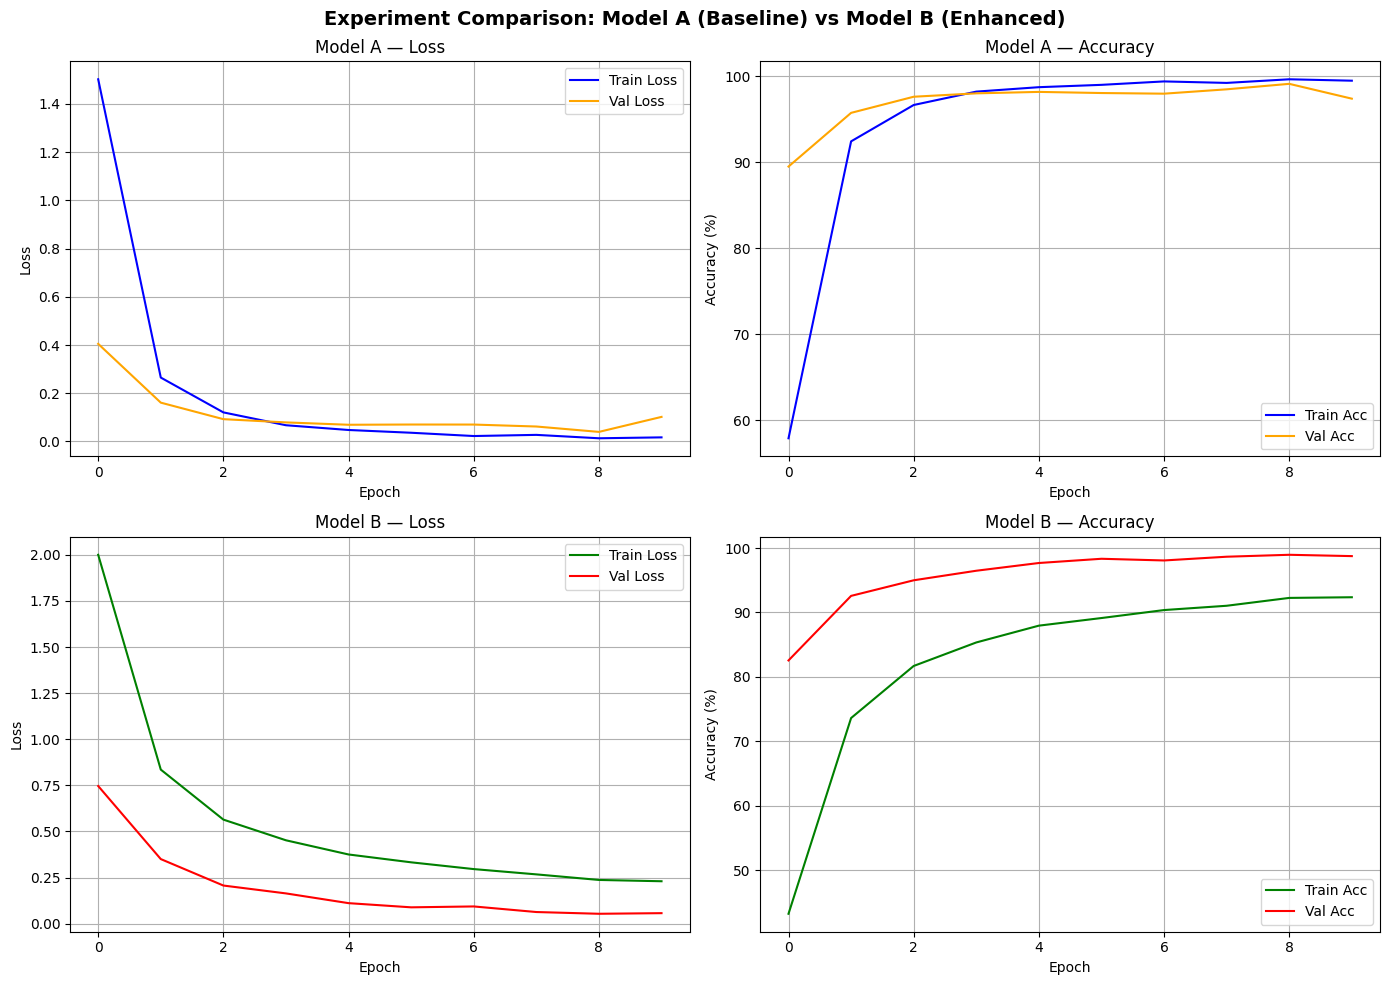

In [36]:
# Visualization: Training vs Validation Loss & Accuracy (Model A & B)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Experiment Comparison: Model A (Baseline) vs Model B (Enhanced)", fontsize=14, fontweight='bold')

# --- Model A: Loss ---
axes[0, 0].plot(train_losses_A, label='Train Loss', color='blue')
axes[0, 0].plot(val_losses_A,   label='Val Loss',   color='orange')
axes[0, 0].set_title("Model A — Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True)

# --- Model A: Accuracy ---
axes[0, 1].plot(train_accs_A, label='Train Acc', color='blue')
axes[0, 1].plot(val_accs_A,   label='Val Acc',   color='orange')
axes[0, 1].set_title("Model A — Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].legend()
axes[0, 1].grid(True)

# --- Model B: Loss ---
axes[1, 0].plot(train_losses_B, label='Train Loss', color='green')
axes[1, 0].plot(val_losses_B,   label='Val Loss',   color='red')
axes[1, 0].set_title("Model B — Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()
axes[1, 0].grid(True)

# --- Model B: Accuracy ---
axes[1, 1].plot(train_accs_B, label='Train Acc', color='green')
axes[1, 1].plot(val_accs_B,   label='Val Acc',   color='red')
axes[1, 1].set_title("Model B — Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy (%)")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [37]:
results = {
    "Model": ["Baseline CNN","Enhanced CNN"],

    "Accuracy":[test_acc_A, test_acc_B],

    "Loss":[test_loss_A, test_loss_B]
}

import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Loss
0,Baseline CNN,86.927949,0.657952
1,Enhanced CNN,94.774347,0.195909


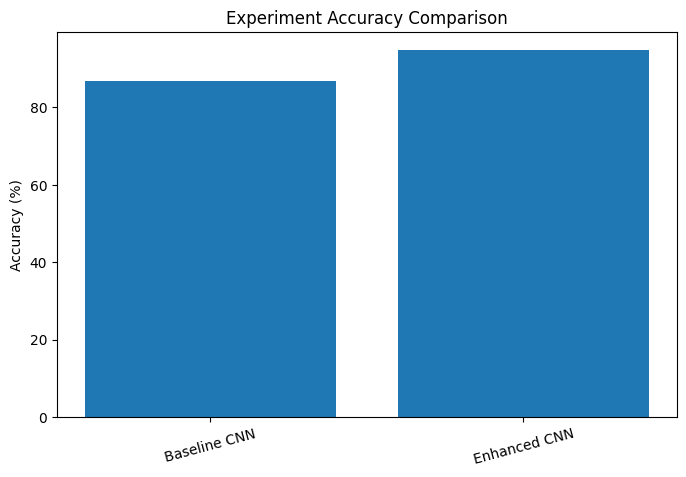

In [38]:

plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['Accuracy']
)

plt.ylabel("Accuracy (%)")
plt.title("Experiment Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

# **15 - Testing on a new images**

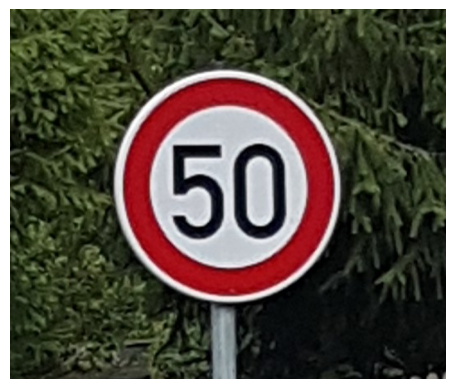

Predicted class: 2
Predicted: Speed limit (50km/h)


In [45]:
from PIL import Image

image_path = "/content/Traffic_sign.jpg"

img = Image.open(image_path).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()


img = transform(img).unsqueeze(0).to(device)

model_B.eval()

with torch.no_grad():
    output = model_B(img)
    prediction = torch.argmax(output,1)

print("Predicted class:", prediction.item())
print("Predicted:", class_names[prediction.item()])

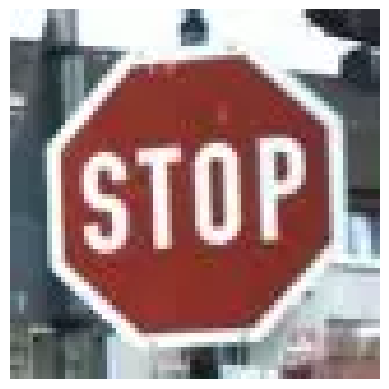

Predicted class: 14
Predicted: Stop


In [46]:
from PIL import Image

image_path = "/content/stop_sign.jpg"

img = Image.open(image_path).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()


img = transform(img).unsqueeze(0).to(device)

model_B.eval()

with torch.no_grad():
    output = model_B(img)
    prediction = torch.argmax(output,1)

print("Predicted class:", prediction.item())
print("Predicted:", class_names[prediction.item()])
